<a href="https://colab.research.google.com/github/prometricas/Pascuas_Canad-/blob/main/Merino_Canada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Instalación de librerías**

In [1]:
# Prophet (Meta) — se instala desde PyPI directamente
!pip install prophet --quiet

# LightGBM para el modelo de ML
!pip install lightgbm --quiet

# Openpyxl para leer el Excel
!pip install openpyxl --quiet

# Verificación de versiones
import prophet
import lightgbm as lgb
import pandas as pd
import numpy as np
import matplotlib
import sklearn

print("✅ Librerías cargadas correctamente")
print(f"   prophet     : {prophet.__version__}")
print(f"   lightgbm    : {lgb.__version__}")
print(f"   pandas      : {pd.__version__}")
print(f"   numpy       : {np.__version__}")
print(f"   matplotlib  : {matplotlib.__version__}")
print(f"   scikit-learn: {sklearn.__version__}")

✅ Librerías cargadas correctamente
   prophet     : 1.3.0
   lightgbm    : 4.6.0
   pandas      : 2.2.2
   numpy       : 2.0.2
   matplotlib  : 3.10.0
   scikit-learn: 1.6.1


# **2. Carga de datos**
* Carga el Excel, convierte fechas, filtra las dos categorías merino.
* Genera una serie diaria completa rellenando con ceros los días sin ventas.
* Imprime estadísticas clave de cada serie.
* Grafica ambas con líneas verticales rojas en los dos Black Fridays históricos para que confirmes visualmente que el patrón está bien identificado.

Saving data_ventas_category.xlsx to data_ventas_category (1).xlsx
Archivo "data_ventas_category (1).xlsx" subido.
Shape total: (18477, 8)
Categorías: ['MENS SUPPORTIVE TIGHT' 'WOMENS SUPPORTIVE TIGHT' 'MENS SUPPORTIVE SHORT'
 'WOMENS SUPPORTIVE SHORT' 'MENS MERINO SUPPORTIVE TIGHT'
 'WOMENS MERINO SUPPORTIVE TIGHT' 'Socks']
Rango de fechas: 2024-01-01 → 2026-01-31

MENS MERINO SUPPORTIVE TIGHT
  Fechas: 2024-10-29 → 2026-01-31
  Días con ventas > 0: 272 de 460
  Total vendido: 8,929
  Pico máximo:   469 el 2025-11-28

WOMENS MERINO SUPPORTIVE TIGHT
  Fechas: 2024-10-30 → 2026-01-31
  Días con ventas > 0: 217 de 459
  Total vendido: 2,254
  Pico máximo:   173 el 2025-11-28


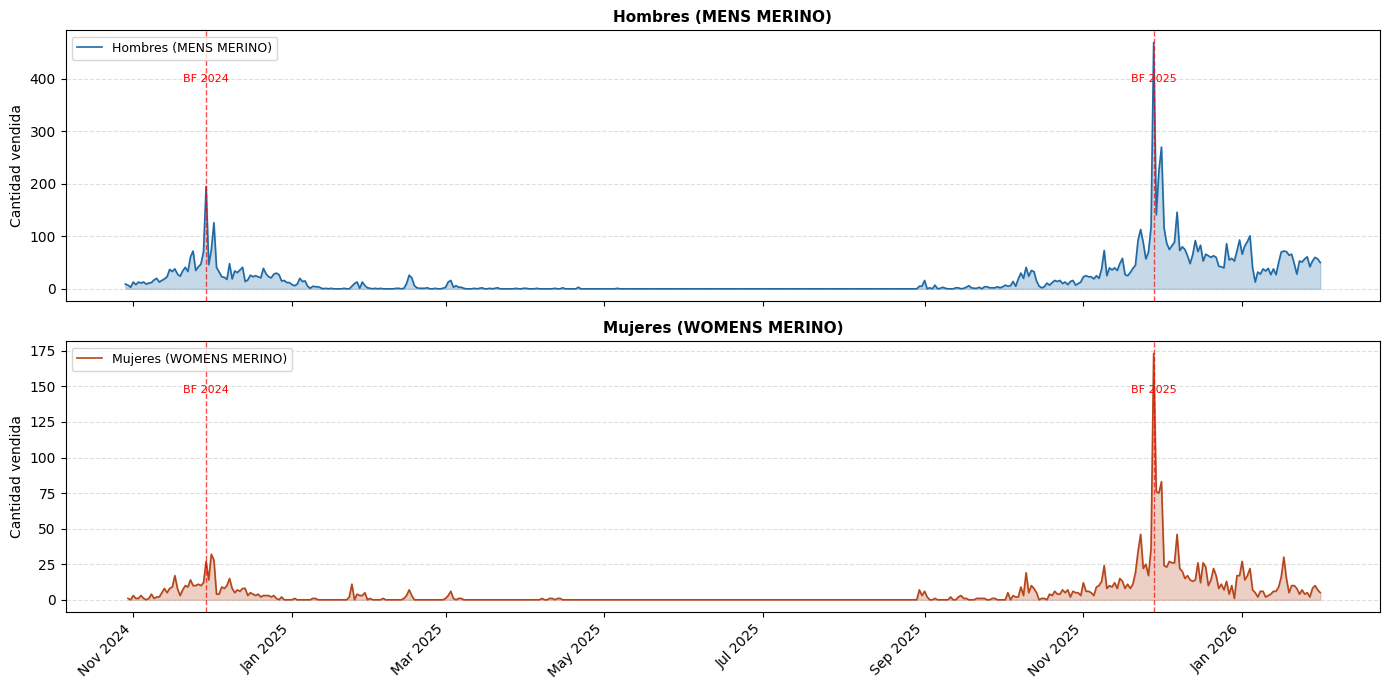

✅ Gráfico guardado como series_merino.png


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from google.colab import files
import io # Import io for BytesIO

# --- 1. Carga ---
uploaded = files.upload()
# Assuming only one file is uploaded, get its content
for fn in uploaded.keys():
  print(f'Archivo "{fn}" subido.')
  file_content = uploaded[fn]
  break # Process only the first uploaded file

# Pass the BytesIO object to pd.read_excel
df = pd.read_excel(io.BytesIO(file_content))
df["Date"] = pd.to_datetime(df["Date"])

print(f"Shape total: {df.shape}")
print(f"Categorías: {df['Product category'].dropna().unique()}")
print(f"Rango de fechas: {df['Date'].min().date()} → {df['Date'].max().date()}")

# --- 2. Filtrar y agregar por día ---
CATS = ["MENS MERINO SUPPORTIVE TIGHT", "WOMENS MERINO SUPPORTIVE TIGHT"]

series = {}
for cat in CATS:
    daily = (
        df[df["Product category"] == cat]
        .groupby("Date")["Quantity"]
        .sum()
        .reset_index()
        .rename(columns={"Quantity": "y"})
    )
    # Rellenar días sin ventas con 0
    full_range = pd.date_range(daily["Date"].min(), daily["Date"].max(), freq="D")
    daily = daily.set_index("Date").reindex(full_range, fill_value=0).reset_index()
    daily.columns = ["ds", "y"]
    series[cat] = daily
    print(f"\n{cat}")
    print(f"  Fechas: {daily['ds'].min().date()} → {daily['ds'].max().date()}")
    print(f"  Días con ventas > 0: {(daily['y'] > 0).sum()} de {len(daily)}")
    print(f"  Total vendido: {daily['y'].sum():,}")
    print(f"  Pico máximo:   {daily['y'].max()} el {daily.loc[daily['y'].idxmax(), 'ds'].date()}")

# --- 3. Visualización ---
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
colors = ["#1f6aa5", "#b5451b"]
labels = ["Hombres (MENS MERINO)", "Mujeres (WOMENS MERINO)"]

for ax, cat, color, label in zip(axes, CATS, colors, labels):
    s = series[cat]
    ax.fill_between(s["ds"], s["y"], alpha=0.25, color=color)
    ax.plot(s["ds"], s["y"], color=color, linewidth=1.2, label=label)

    # Marcar Black Fridays
    for bf_date, bf_label in [("2024-11-29", "BF 2024"), ("2025-11-28", "BF 2025")]:
        ax.axvline(pd.Timestamp(bf_date), color="red", linestyle="--", linewidth=1, alpha=0.7)
        ax.text(pd.Timestamp(bf_date), ax.get_ylim()[1]*0.8, bf_label,
                color="red", fontsize=8, ha="center")

    ax.set_ylabel("Cantidad vendida", fontsize=10)
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("series_merino.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico guardado como series_merino.png")

# **3. Feature engineering y calendario de eventos**
* Calcula el **Black Friday** exacto para cualquier año (4° jueves de noviembre), incluyendo 2026.
* Construye el calendario de eventos que _Prophet_ necesita, con ventanas asimétricas: por ejemplo, Black Friday tiene rampa de 10 días antes y cola de 2 días después, capturando el comportamiento real que se ve en las gráficas.
* Genera el bloque de _features_ para LightGBM: calendario, proximidad al BF en días (variable continua, muy poderosa), indicadores de ventanas clave, términos de Fourier para la curva anual suave, y lags/medias móviles para el patrón semanal.

In [4]:
# --- 1. Función para calcular Black Friday (4° jueves de noviembre) ---
def get_black_friday(year):
    """Devuelve la fecha del Black Friday (4° jueves de noviembre) para un año dado."""
    nov1 = pd.Timestamp(f"{year}-11-01")
    # Día de la semana: lunes=0 ... jueves=3
    days_to_thursday = (3 - nov1.dayofweek) % 7
    first_thursday = nov1 + pd.Timedelta(days=days_to_thursday)
    return first_thursday + pd.Timedelta(weeks=3)  # 4° jueves

for yr in [2024, 2025, 2026]:
    print(f"Black Friday {yr}: {get_black_friday(yr).date()}")

# --- 2. Calendario de eventos especiales para Prophet ---
def build_events(years):
    rows = []
    for yr in years:
        bf = get_black_friday(yr)
        events = {
            # Black Friday: ventana asimétrica (rampa 10 días antes, cola 2 días después)
            "black_friday":      (bf, -10, 2),
            # Cyber Monday (lunes siguiente al BF)
            "cyber_monday":      (bf + pd.Timedelta(days=3), -1, 3),
            # Segunda ola diciembre (aprox. 7-10 dic)
            "dic_second_wave":   (pd.Timestamp(f"{yr}-12-08"), -2, 5),
            # Navidad / fin de año
            "christmas":         (pd.Timestamp(f"{yr}-12-25"), -4, 3),
        }
        for name, (date, lower, upper) in events.items():
            rows.append({"holiday": name, "ds": date,
                         "lower_window": lower, "upper_window": upper})
    return pd.DataFrame(rows)

holidays_df = build_events([2024, 2025, 2026])
print("\nCalendario de eventos:")
print(holidays_df.to_string(index=False))

# --- 3. Feature engineering para el modelo LightGBM ---
def build_features(daily_series):
    """
    Recibe un DataFrame con columnas [ds, y] y agrega features de calendario,
    lags y medias móviles.
    """
    s = daily_series.copy()
    s = s.sort_values("ds").reset_index(drop=True)

    # --- Calendario básico ---
    s["dayofweek"]   = s["ds"].dt.dayofweek        # 0=lun … 6=dom
    s["month"]       = s["ds"].dt.month
    s["dayofyear"]   = s["ds"].dt.dayofyear
    s["weekofyear"]  = s["ds"].dt.isocalendar().week.astype(int)
    s["is_weekend"]  = (s["dayofweek"] >= 5).astype(int)

    # --- Proximidad a Black Friday (días relativos al BF de ese año) ---
    def days_to_bf(date):
        bf = get_black_friday(date.year)
        delta = (date - bf).days

Black Friday 2024: 2024-11-28
Black Friday 2025: 2025-11-27
Black Friday 2026: 2026-11-26

Calendario de eventos:
        holiday         ds  lower_window  upper_window
   black_friday 2024-11-28           -10             2
   cyber_monday 2024-12-01            -1             3
dic_second_wave 2024-12-08            -2             5
      christmas 2024-12-25            -4             3
   black_friday 2025-11-27           -10             2
   cyber_monday 2025-11-30            -1             3
dic_second_wave 2025-12-08            -2             5
      christmas 2025-12-25            -4             3
   black_friday 2026-11-26           -10             2
   cyber_monday 2026-11-29            -1             3
dic_second_wave 2026-12-08            -2             5
      christmas 2026-12-25            -4             3


# **4. Modelo Prophet con backtesting:**

## 4.1. Men's merino


Black Fridays: {2024: datetime.date(2024, 11, 28), 2025: datetime.date(2025, 11, 27), 2026: datetime.date(2026, 11, 26)}

Forma compuesta: 70% × 2025  +  30% × 2024
Días en ventana — 2024: 67  |  2025: 67  |  unión: 67
Día de peso máximo (relativo al BF): 1

Total pico 2024 : 2,007
Total pico 2025 : 4,963
Factor de crecimiento : 2.473x
Total proyectado pico 2026 : 12,273


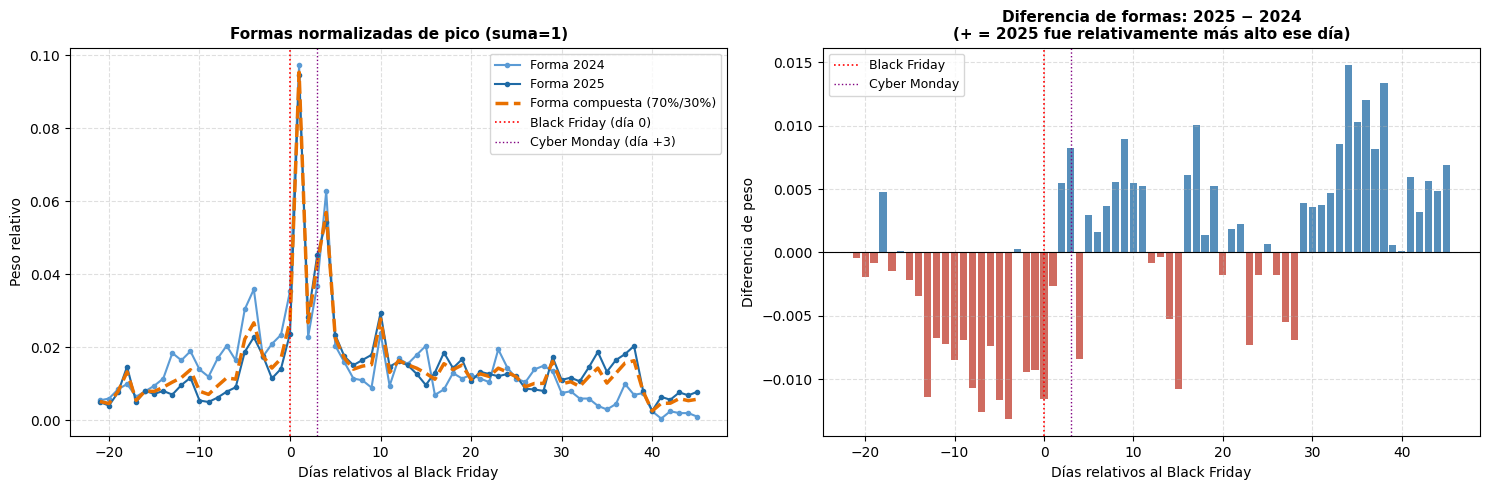


📊 Backtesting — reproducción del pico 2025:
Método                              MAE     RMSE     MAPE
------------------------------------------------------
Solo forma 2024                    28.2     34.1    49.0%
Forma compuesta 70/30               8.4     10.2    14.7%

Datos línea base (sin picos): 326 días  |  media diaria: 6.0


ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted


✅ Modelo base ajustado

🗓️  Forecast 2026: 2026-02-01 → 2026-12-31
   Total feb-dic 2026  : 29,586 unidades
   Pico BF 2026        : 1170 unidades el 2026-11-27


In [10]:
# ============================================================
# CELDA 4 (v4) — FORMA DE PICO COMPUESTA (2024 + 2025 ponderado)
# ============================================================

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import logging
import warnings

warnings.filterwarnings("ignore")
logging.getLogger("prophet").setLevel(logging.ERROR)
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)

CAT_M = "MENS MERINO SUPPORTIVE TIGHT"
df_m = series[CAT_M].copy()

BF = {yr: get_black_friday(yr) for yr in [2024, 2025, 2026]}
print("Black Fridays:", {yr: d.date() for yr, d in BF.items()})

WINDOW_START = -21
WINDOW_END   = 45
W_2025, W_2024 = 0.70, 0.30

# ---------------------------------------------------------------
# PASO 1: Extraer picos y normalizarlos a "forma pura"
# ---------------------------------------------------------------
def extract_peak(df, bf_date, ws=WINDOW_START, we=WINDOW_END):
    start = bf_date + pd.Timedelta(days=ws)
    end   = bf_date + pd.Timedelta(days=we)
    peak  = df[(df["ds"] >= start) & (df["ds"] <= end)].copy()
    peak["day_rel"] = (peak["ds"] - bf_date).dt.days
    return peak.set_index("day_rel")["y"]

peak_2024 = extract_peak(df_m, BF[2024])
peak_2025 = extract_peak(df_m, BF[2025])

shape_2024 = peak_2024 / peak_2024.sum()
shape_2025 = peak_2025 / peak_2025.sum()

all_days   = shape_2024.index.union(shape_2025.index)
shape_2024 = shape_2024.reindex(all_days, fill_value=0)
shape_2025 = shape_2025.reindex(all_days, fill_value=0)

shape_combined = W_2025 * shape_2025 + W_2024 * shape_2024

print(f"\nForma compuesta: {W_2025:.0%} × 2025  +  {W_2024:.0%} × 2024")
print(f"Días en ventana — 2024: {(shape_2024>0).sum()}  |  2025: {(shape_2025>0).sum()}  |  unión: {len(shape_combined)}")
print(f"Día de peso máximo (relativo al BF): {shape_combined.idxmax()}")

# ---------------------------------------------------------------
# PASO 2: Factor de crecimiento y magnitud proyectada 2026
# ---------------------------------------------------------------
total_2024    = peak_2024.sum()
total_2025    = peak_2025.sum()
growth_factor = total_2025 / total_2024
total_2026_hat = total_2025 * growth_factor

print(f"\nTotal pico 2024 : {total_2024:,.0f}")
print(f"Total pico 2025 : {total_2025:,.0f}")
print(f"Factor de crecimiento : {growth_factor:.3f}x")
print(f"Total proyectado pico 2026 : {total_2026_hat:,.0f}")

# ---------------------------------------------------------------
# PASO 3: Visualizar las tres formas (diagnóstico)
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.plot(shape_2024.index, shape_2024.values, color="#5b9bd5", linewidth=1.5,
        marker="o", markersize=3, label="Forma 2024")
ax.plot(shape_2025.index, shape_2025.values, color="#1f6aa5", linewidth=1.5,
        marker="o", markersize=3, label="Forma 2025")
ax.plot(shape_combined.index, shape_combined.values, color="#e87000", linewidth=2.5,
        linestyle="--", label=f"Forma compuesta ({W_2025:.0%}/{W_2024:.0%})")
ax.axvline(0, color="red",    linestyle=":", linewidth=1.2, label="Black Friday (día 0)")
ax.axvline(3, color="purple", linestyle=":", linewidth=1.0, label="Cyber Monday (día +3)")
ax.set_title("Formas normalizadas de pico (suma=1)", fontsize=11, fontweight="bold")
ax.set_xlabel("Días relativos al Black Friday")
ax.set_ylabel("Peso relativo")
ax.legend(fontsize=9)
ax.grid(linestyle="--", alpha=0.4)

ax2 = axes[1]
diff = shape_2025 - shape_2024
ax2.bar(diff.index, diff.values,
        color=["#1f6aa5" if v >= 0 else "#c0392b" for v in diff.values], alpha=0.75)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.axvline(0, color="red",    linestyle=":", linewidth=1.2, label="Black Friday")
ax2.axvline(3, color="purple", linestyle=":", linewidth=1.0, label="Cyber Monday")
ax2.set_title("Diferencia de formas: 2025 − 2024\n(+ = 2025 fue relativamente más alto ese día)",
              fontsize=11, fontweight="bold")
ax2.set_xlabel("Días relativos al Black Friday")
ax2.set_ylabel("Diferencia de peso")
ax2.legend(fontsize=9)
ax2.grid(linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# PASO 4: Backtesting — forma 2024 sola vs forma compuesta
# ---------------------------------------------------------------
real = peak_2025.reindex(all_days, fill_value=0)
pred_solo2024 = (shape_2024 * total_2025).clip(lower=0)
pred_combined = (shape_combined * total_2025).clip(lower=0)

def metrics(real, pred):
    mae  = mean_absolute_error(real, pred)
    rmse = mean_squared_error(real, pred) ** 0.5
    mape = (abs(real - pred) / real.replace(0, np.nan)).mean() * 100
    return mae, rmse, mape

mae_s, rmse_s, mape_s = metrics(real, pred_solo2024)
mae_c, rmse_c, mape_c = metrics(real, pred_combined)

print(f"\n📊 Backtesting — reproducción del pico 2025:")
print(f"{'Método':<30} {'MAE':>8} {'RMSE':>8} {'MAPE':>8}")
print(f"{'-'*54}")
print(f"{'Solo forma 2024':<30} {mae_s:>8.1f} {rmse_s:>8.1f} {mape_s:>7.1f}%")
print(f"{'Forma compuesta 70/30':<30} {mae_c:>8.1f} {rmse_c:>8.1f} {mape_c:>7.1f}%")

# ---------------------------------------------------------------
# PASO 5: Prophet para línea base (excluyendo ventanas de pico)
# ---------------------------------------------------------------
def is_peak(date):
    for yr in [2024, 2025]:
        bf = BF[yr]
        if (bf + pd.Timedelta(days=WINDOW_START)) <= date <= (bf + pd.Timedelta(days=WINDOW_END)):
            return True
    return False

df_base = df_m[~df_m["ds"].apply(is_peak)].copy()
print(f"\nDatos línea base (sin picos): {len(df_base)} días  |  media diaria: {df_base['y'].mean():.1f}")

model_base = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode="additive",
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=5.0,
    holidays=holidays_df,
    interval_width=0.90,
)
model_base.add_seasonality(name="monthly", period=30.5, fourier_order=3, mode="additive")
model_base.fit(df_base)
print("✅ Modelo base ajustado")

# ---------------------------------------------------------------
# PASO 6: Forecast 2026 estrictamente hasta dic 2026
# ---------------------------------------------------------------
TARGET_END  = pd.Timestamp("2026-12-31")
days_ahead  = (TARGET_END - df_m["ds"].max()).days

future_2026 = model_base.make_future_dataframe(periods=days_ahead, freq="D")
future_2026 = future_2026[future_2026["ds"] <= TARGET_END].copy()

fc_base      = model_base.predict(future_2026)
fc_base_2026 = fc_base[
    (fc_base["ds"] >= "2026-02-01") &
    (fc_base["ds"] <= TARGET_END)
][["ds", "yhat", "yhat_lower", "yhat_upper"]].copy()
fc_base_2026["yhat"]       = fc_base_2026["yhat"].clip(lower=0)
fc_base_2026["yhat_lower"] = fc_base_2026["yhat_lower"].clip(lower=0)

# Pico 2026 = forma compuesta × magnitud proyectada
peak_2026_values = (shape_combined * total_2026_hat).clip(lower=0)
peak_2026_dates  = pd.DataFrame({
    "ds":        BF[2026] + pd.to_timedelta(peak_2026_values.index, unit="D"),
    "yhat_peak": peak_2026_values.values
})
# Descartar fechas que caigan fuera del rango 2026
peak_2026_dates = peak_2026_dates[peak_2026_dates["ds"] <= TARGET_END]

fc_final  = fc_base_2026.merge(peak_2026_dates, on="ds", how="left")
peak_mask = fc_final["yhat_peak"].notna()
fc_final.loc[peak_mask, "yhat"]       = fc_final.loc[peak_mask, "yhat_peak"]
fc_final.loc[peak_mask, "yhat_lower"] = fc_final.loc[peak_mask, "yhat_peak"] * 0.75
fc_final.loc[peak_mask, "yhat_upper"] = fc_final.loc[peak_mask, "yhat_peak"] * 1.30
fc_final = fc_final.drop(columns=["yhat_peak"])

print(f"\n🗓️  Forecast 2026: {fc_final['ds'].min().date()} → {fc_final['ds'].max().date()}")
print(f"   Total feb-dic 2026  : {fc_final['yhat'].sum():,.0f} unidades")
print(f"   Pico BF 2026        : {fc_final['yhat'].max():.0f} unidades el "
      f"{fc_final.loc[fc_final['yhat'].idxmax(), 'ds'].date()}")

# Guardar para uso en celda de resumen final
fc_mens_2026 = fc_final.copy()

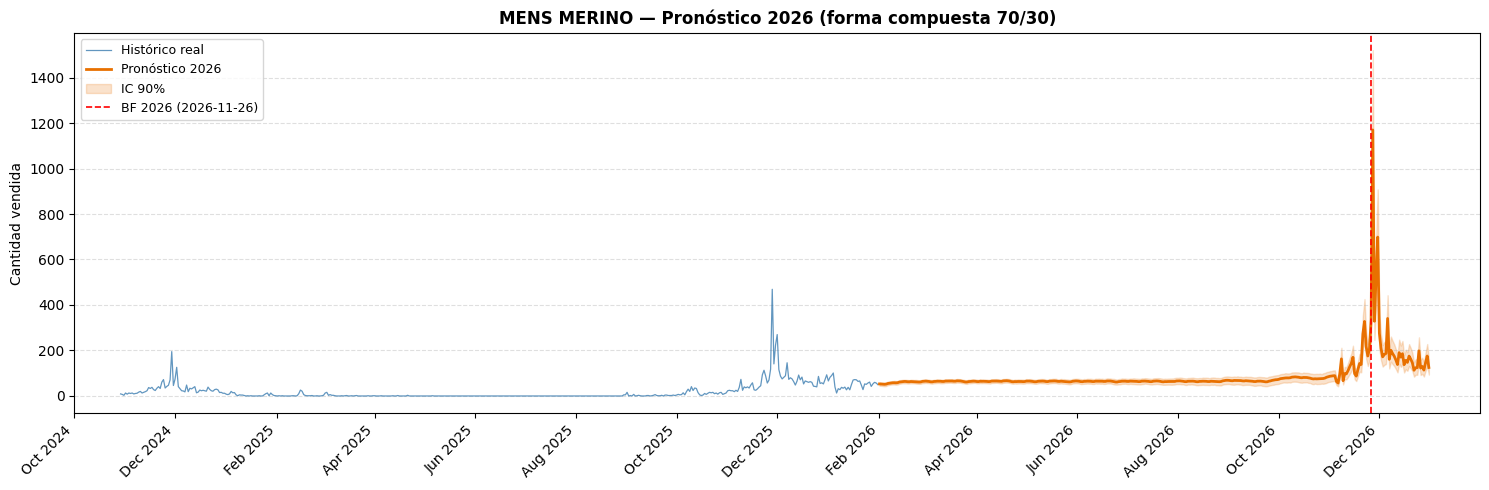

✅ Celda 4 v4 completada


In [12]:
# ---------------------------------------------------------------
# PASO 7: Gráfico forecast 2026 (con cola visible hasta ene 2027)
# ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df_m["ds"], df_m["y"],
        color="#1f6aa5", linewidth=0.9, alpha=0.7, label="Histórico real")
ax.plot(fc_final["ds"], fc_final["yhat"],
        color="#e87000", linewidth=2, label="Pronóstico 2026")
ax.fill_between(fc_final["ds"], fc_final["yhat_lower"], fc_final["yhat_upper"],
                alpha=0.2, color="#e87000", label="IC 90%")
ax.axvline(BF[2026], color="red", linestyle="--", linewidth=1.2,
           label=f"BF 2026 ({BF[2026].date()})")

# Extender eje x hasta ene 2027 para ver la cola del pico completa
ax.set_xlim(pd.Timestamp("2024-10-01"), pd.Timestamp("2027-01-31"))

ax.set_title("MENS MERINO — Pronóstico 2026 (forma compuesta 70/30)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Cantidad vendida")
ax.legend(fontsize=9, loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
print("✅ Celda 4 v4 completada")

## 4.2. Women's merino

Forma compuesta WOMENS: 70% × 2025  +  30% × 2024
Días en ventana — 2024: 54  |  2025: 67  |  unión: 67
Día de peso máximo (relativo al BF): 1

Total pico 2024 : 400
Total pico 2025 : 1,411
Factor de crecimiento : 3.527x
Total proyectado pico 2026 : 4,977

📊 Comparación factores de crecimiento:
   MENS  : 2.473x
   WOMENS: 3.527x


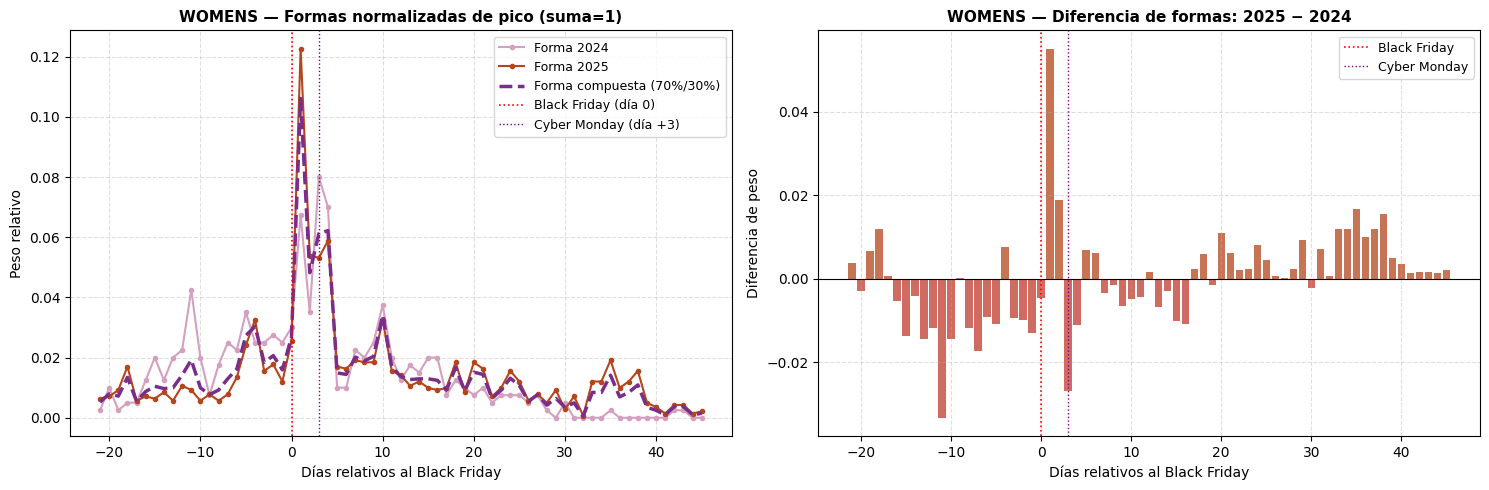


📊 Backtesting WOMENS — reproducción del pico 2025:
Método                              MAE     RMSE     MAPE
------------------------------------------------------
Solo forma 2024                    11.7     16.7    74.1%
Forma compuesta 70/30               3.5      5.0    22.2%

Datos línea base (sin picos): 325 días  |  media diaria: 1.4
✅ Modelo base WOMENS ajustado

🗓️  Forecast WOMENS 2026: 2026-02-01 → 2026-12-31
   Total feb-dic 2026  : 6,773 unidades
   Pico BF 2026        : 528 unidades el 2026-11-27


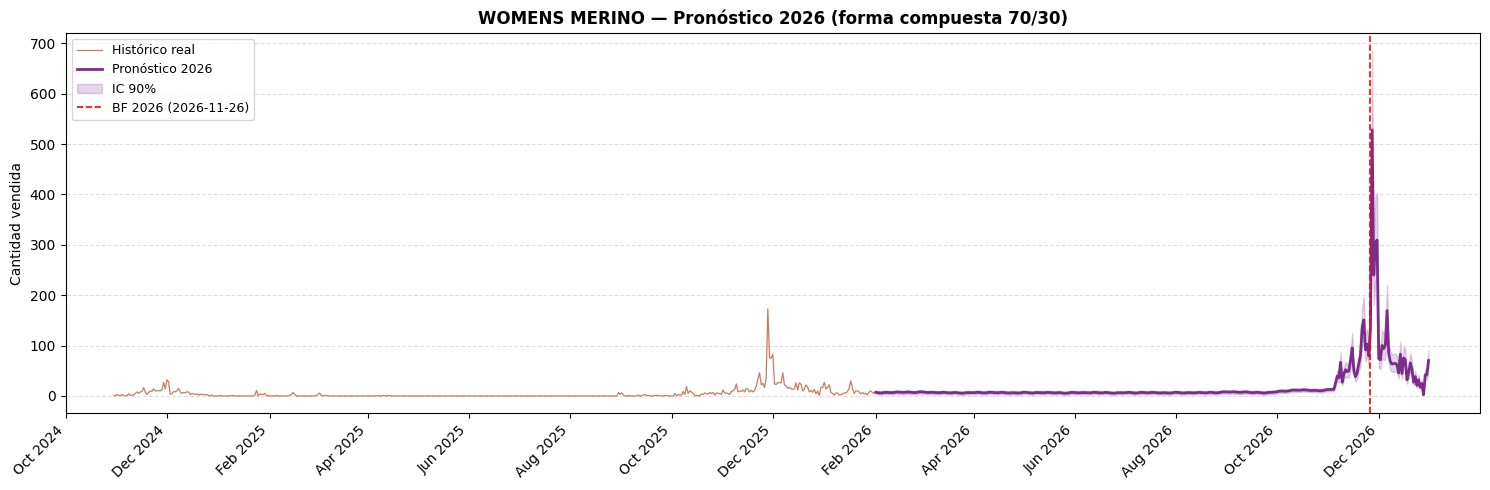

✅ Celda 5 completada


In [13]:
# ============================================================
# CELDA 5 — WOMENS MERINO SUPPORTIVE TIGHT
# ============================================================

import logging, warnings
warnings.filterwarnings("ignore")
logging.getLogger("prophet").setLevel(logging.ERROR)
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)

CAT_W = "WOMENS MERINO SUPPORTIVE TIGHT"
df_w = series[CAT_W].copy()

WINDOW_START = -21
WINDOW_END   = 45
W_2025, W_2024 = 0.70, 0.30

# ---------------------------------------------------------------
# PASO 1: Extraer picos y normalizarlos
# ---------------------------------------------------------------
peak_2024_w = extract_peak(df_w, BF[2024])
peak_2025_w = extract_peak(df_w, BF[2025])

shape_2024_w = peak_2024_w / peak_2024_w.sum()
shape_2025_w = peak_2025_w / peak_2025_w.sum()

all_days_w   = shape_2024_w.index.union(shape_2025_w.index)
shape_2024_w = shape_2024_w.reindex(all_days_w, fill_value=0)
shape_2025_w = shape_2025_w.reindex(all_days_w, fill_value=0)

shape_combined_w = W_2025 * shape_2025_w + W_2024 * shape_2024_w

print(f"Forma compuesta WOMENS: {W_2025:.0%} × 2025  +  {W_2024:.0%} × 2024")
print(f"Días en ventana — 2024: {(shape_2024_w>0).sum()}  |  "
      f"2025: {(shape_2025_w>0).sum()}  |  unión: {len(shape_combined_w)}")
print(f"Día de peso máximo (relativo al BF): {shape_combined_w.idxmax()}")

# ---------------------------------------------------------------
# PASO 2: Factor de crecimiento y magnitud proyectada 2026
# ---------------------------------------------------------------
total_2024_w    = peak_2024_w.sum()
total_2025_w    = peak_2025_w.sum()
growth_factor_w = total_2025_w / total_2024_w
total_2026_hat_w = total_2025_w * growth_factor_w

print(f"\nTotal pico 2024 : {total_2024_w:,.0f}")
print(f"Total pico 2025 : {total_2025_w:,.0f}")
print(f"Factor de crecimiento : {growth_factor_w:.3f}x")
print(f"Total proyectado pico 2026 : {total_2026_hat_w:,.0f}")

# Comparación con hombres
print(f"\n📊 Comparación factores de crecimiento:")
print(f"   MENS  : {growth_factor:.3f}x")
print(f"   WOMENS: {growth_factor_w:.3f}x")

# ---------------------------------------------------------------
# PASO 3: Visualizar formas (diagnóstico)
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.plot(shape_2024_w.index, shape_2024_w.values, color="#d4a0c0", linewidth=1.5,
        marker="o", markersize=3, label="Forma 2024")
ax.plot(shape_2025_w.index, shape_2025_w.values, color="#b5451b", linewidth=1.5,
        marker="o", markersize=3, label="Forma 2025")
ax.plot(shape_combined_w.index, shape_combined_w.values, color="#7b2d8b", linewidth=2.5,
        linestyle="--", label=f"Forma compuesta ({W_2025:.0%}/{W_2024:.0%})")
ax.axvline(0, color="red",    linestyle=":", linewidth=1.2, label="Black Friday (día 0)")
ax.axvline(3, color="purple", linestyle=":", linewidth=1.0, label="Cyber Monday (día +3)")
ax.set_title("WOMENS — Formas normalizadas de pico (suma=1)", fontsize=11, fontweight="bold")
ax.set_xlabel("Días relativos al Black Friday")
ax.set_ylabel("Peso relativo")
ax.legend(fontsize=9)
ax.grid(linestyle="--", alpha=0.4)

ax2 = axes[1]
diff_w = shape_2025_w - shape_2024_w
ax2.bar(diff_w.index, diff_w.values,
        color=["#b5451b" if v >= 0 else "#c0392b" for v in diff_w.values], alpha=0.75)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.axvline(0, color="red",    linestyle=":", linewidth=1.2, label="Black Friday")
ax2.axvline(3, color="purple", linestyle=":", linewidth=1.0, label="Cyber Monday")
ax2.set_title("WOMENS — Diferencia de formas: 2025 − 2024",
              fontsize=11, fontweight="bold")
ax2.set_xlabel("Días relativos al Black Friday")
ax2.set_ylabel("Diferencia de peso")
ax2.legend(fontsize=9)
ax2.grid(linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# PASO 4: Backtesting — forma 2024 sola vs forma compuesta
# ---------------------------------------------------------------
real_w        = peak_2025_w.reindex(all_days_w, fill_value=0)
pred_solo2024_w = (shape_2024_w * total_2025_w).clip(lower=0)
pred_combined_w = (shape_combined_w * total_2025_w).clip(lower=0)

mae_s, rmse_s, mape_s = metrics(real_w, pred_solo2024_w)
mae_c, rmse_c, mape_c = metrics(real_w, pred_combined_w)

print(f"\n📊 Backtesting WOMENS — reproducción del pico 2025:")
print(f"{'Método':<30} {'MAE':>8} {'RMSE':>8} {'MAPE':>8}")
print(f"{'-'*54}")
print(f"{'Solo forma 2024':<30} {mae_s:>8.1f} {rmse_s:>8.1f} {mape_s:>7.1f}%")
print(f"{'Forma compuesta 70/30':<30} {mae_c:>8.1f} {rmse_c:>8.1f} {mape_c:>7.1f}%")

# ---------------------------------------------------------------
# PASO 5: Prophet para línea base (excluyendo ventanas de pico)
# ---------------------------------------------------------------
df_base_w = df_w[~df_w["ds"].apply(is_peak)].copy()
print(f"\nDatos línea base (sin picos): {len(df_base_w)} días  |  "
      f"media diaria: {df_base_w['y'].mean():.1f}")

model_base_w = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode="additive",
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=5.0,
    holidays=holidays_df,
    interval_width=0.90,
)
model_base_w.add_seasonality(name="monthly", period=30.5, fourier_order=3, mode="additive")
model_base_w.fit(df_base_w)
print("✅ Modelo base WOMENS ajustado")

# ---------------------------------------------------------------
# PASO 6: Forecast 2026
# ---------------------------------------------------------------
TARGET_END   = pd.Timestamp("2026-12-31")
days_ahead_w = (TARGET_END - df_w["ds"].max()).days

future_2026_w = model_base_w.make_future_dataframe(periods=days_ahead_w, freq="D")
future_2026_w = future_2026_w[future_2026_w["ds"] <= TARGET_END].copy()

fc_base_w      = model_base_w.predict(future_2026_w)
fc_base_2026_w = fc_base_w[
    (fc_base_w["ds"] >= "2026-02-01") &
    (fc_base_w["ds"] <= TARGET_END)
][["ds", "yhat", "yhat_lower", "yhat_upper"]].copy()
fc_base_2026_w["yhat"]       = fc_base_2026_w["yhat"].clip(lower=0)
fc_base_2026_w["yhat_lower"] = fc_base_2026_w["yhat_lower"].clip(lower=0)

# Pico 2026 = forma compuesta × magnitud proyectada
peak_2026_values_w = (shape_combined_w * total_2026_hat_w).clip(lower=0)
peak_2026_dates_w  = pd.DataFrame({
    "ds":        BF[2026] + pd.to_timedelta(peak_2026_values_w.index, unit="D"),
    "yhat_peak": peak_2026_values_w.values
})
peak_2026_dates_w = peak_2026_dates_w[peak_2026_dates_w["ds"] <= TARGET_END]

fc_final_w  = fc_base_2026_w.merge(peak_2026_dates_w, on="ds", how="left")
peak_mask_w = fc_final_w["yhat_peak"].notna()
fc_final_w.loc[peak_mask_w, "yhat"]       = fc_final_w.loc[peak_mask_w, "yhat_peak"]
fc_final_w.loc[peak_mask_w, "yhat_lower"] = fc_final_w.loc[peak_mask_w, "yhat_peak"] * 0.75
fc_final_w.loc[peak_mask_w, "yhat_upper"] = fc_final_w.loc[peak_mask_w, "yhat_peak"] * 1.30
fc_final_w = fc_final_w.drop(columns=["yhat_peak"])

print(f"\n🗓️  Forecast WOMENS 2026: {fc_final_w['ds'].min().date()} → {fc_final_w['ds'].max().date()}")
print(f"   Total feb-dic 2026  : {fc_final_w['yhat'].sum():,.0f} unidades")
print(f"   Pico BF 2026        : {fc_final_w['yhat'].max():.0f} unidades el "
      f"{fc_final_w.loc[fc_final_w['yhat'].idxmax(), 'ds'].date()}")

# Guardar para celda de resumen final
fc_womens_2026 = fc_final_w.copy()

# ---------------------------------------------------------------
# PASO 7: Gráfico forecast 2026 WOMENS
# ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df_w["ds"], df_w["y"],
        color="#b5451b", linewidth=0.9, alpha=0.7, label="Histórico real")
ax.plot(fc_final_w["ds"], fc_final_w["yhat"],
        color="#7b2d8b", linewidth=2, label="Pronóstico 2026")
ax.fill_between(fc_final_w["ds"], fc_final_w["yhat_lower"], fc_final_w["yhat_upper"],
                alpha=0.2, color="#7b2d8b", label="IC 90%")
ax.axvline(BF[2026], color="red", linestyle="--", linewidth=1.2,
           label=f"BF 2026 ({BF[2026].date()})")
ax.set_xlim(pd.Timestamp("2024-10-01"), pd.Timestamp("2027-01-31"))
ax.set_title("WOMENS MERINO — Pronóstico 2026 (forma compuesta 70/30)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Cantidad vendida")
ax.legend(fontsize=9, loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
print("✅ Celda 5 completada")

# **5. Resumen comparativo**